# TS6 - Transformada Z y Respuesta en frecuencia

Se analizan cuatro sistemas descriptos por ecuaciones en diferencias.
Para cada uno se obtiene:
1. La funcion de transferencia $T(z) = Y(z)/X(z)$
2. La respuesta en frecuencia analitica: modulo $|H(e^{j\omega})|$ y fase $\angle H(e^{j\omega})$
3. Validacion numerica con `numpy` / `scipy`

Sistemas:
- a) $y(n) = x(n) + x(n-1) + x(n-2) + x(n-3)$ — orden 4
- b) $y(n) = x(n) + x(n-1) + x(n-2) + x(n-3) + x(n-4)$ — orden 5
- c) $y(n) = x(n) - x(n-1)$ — diferencia de primer orden
- d) $y(n) = x(n) - x(n-2)$ — diferencia de segundo orden

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

N_w = 4096  # puntos para freqz

## Sistema a)

$$y(n) = x(n) + x(n-1) + x(n-2) + x(n-3)$$

### 1. Funcion de transferencia

Aplicando la transformada Z (con la propiedad de retardo $\mathcal{Z}\{x(n-k)\} = z^{-k}X(z)$):

$$Y(z) = X(z)\left(1 + z^{-1} + z^{-2} + z^{-3}\right)$$

$$\boxed{T_a(z) = 1 + z^{-1} + z^{-2} + z^{-3}}$$

Es un filtro FIR de fase lineal (coeficientes simetricos, $M=3$).

### 2. Respuesta en frecuencia

Evaluando en $z = e^{j\omega}$ y usando la suma geometrica:

$$H_a(e^{j\omega}) = \frac{1 - e^{-j4\omega}}{1 - e^{-j\omega}}
= e^{-j\frac{3\omega}{2}}\,\frac{\sin(2\omega)}{\sin(\omega/2)}$$

Modulo:
$$|H_a(e^{j\omega})| = \left|\frac{\sin(2\omega)}{\sin(\omega/2)}\right|$$

Fase:
$$\angle H_a(e^{j\omega}) = -\frac{3\omega}{2} \quad \text{(fase lineal, retardo de grupo = } \tfrac{3}{2}\text{ muestras)}$$

El filtro tiene ceros en $\omega = k\pi/2$ con $k = 1, 2, 3$, es decir en $f/f_s \in \{0.25, 0.5, 0.75\}$.

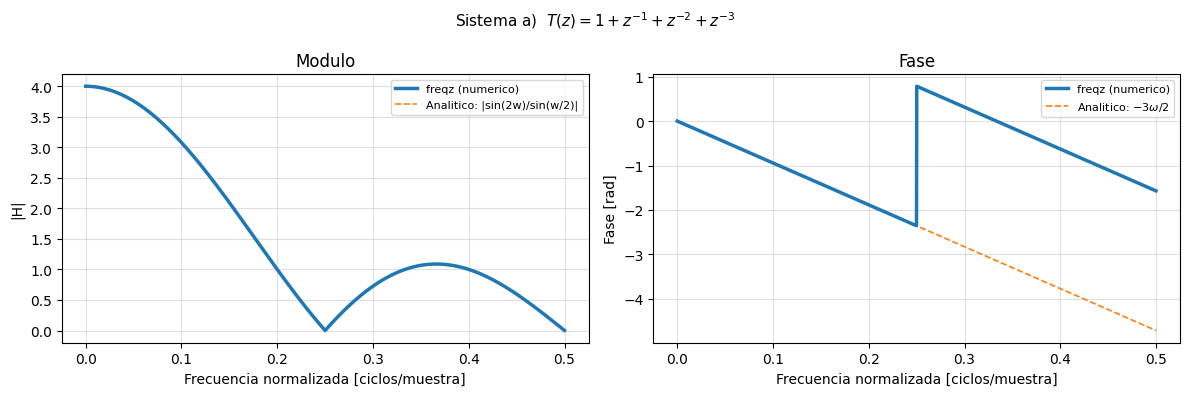

Ganancia en DC (w=0):  numerico = 4.0000,  analitico = 4
Error maximo de modulo: 1.53e-03


In [9]:
# coeficientes del filtro (numerador b, denominador a=1)
b_a = np.array([1, 1, 1, 1])
a_a = np.array([1])

w_a, H_a = freqz(b_a, a_a, worN=N_w, whole=False)  # ω en [0, π]
f_norm_a  = w_a / (2 * np.pi)                       # frec normalizada [0, 0.5]

# res analitica
w_an   = np.linspace(1e-9, np.pi, N_w)
H_anlt = np.sin(2 * w_an) / np.sin(w_an / 2)        # modulo analitico
ph_an  = -1.5 * w_an                                 # fase analitica
f_an   = w_an / (2 * np.pi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sistema a)  $T(z) = 1 + z^{-1} + z^{-2} + z^{-3}$', fontsize=11)

axes[0].plot(f_norm_a, np.abs(H_a),       lw=2.5, label='freqz (numerico)', zorder=3)
axes[0].plot(f_an,     np.abs(H_anlt),    lw=1.2, ls='--', color='C1', label='Analitico: |sin(2w)/sin(w/2)|')
axes[0].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[0].set_ylabel('|H|')
axes[0].set_title('Modulo')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].plot(f_norm_a, np.unwrap(np.angle(H_a)), lw=2.5, label='freqz (numerico)', zorder=3)
axes[1].plot(f_an,     ph_an,                    lw=1.2, ls='--', color='C1', label=r'Analitico: $-3\omega/2$')
axes[1].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Ganancia en DC (w=0):  numerico = {np.abs(H_a[0]):.4f},  analitico = 4')
print(f'Error maximo de modulo: {np.max(np.abs(np.abs(H_a) - np.abs(H_anlt))):.2e}')

## Sistema b)

$$y(n) = x(n) + x(n-1) + x(n-2) + x(n-3) + x(n-4)$$

### 1. Funcion de transferencia

$$Y(z) = X(z)\left(1 + z^{-1} + z^{-2} + z^{-3} + z^{-4}\right)$$

$$\boxed{T_b(z) = 1 + z^{-1} + z^{-2} + z^{-3} + z^{-4}}$$

FIR de fase lineal, orden $M=4$.

### 2. Respuesta en frecuencia

Usando la suma geometrica de 5 terminos:

$$H_b(e^{j\omega}) = \frac{1 - e^{-j5\omega}}{1 - e^{-j\omega}}
= e^{-j2\omega}\,\frac{\sin(5\omega/2)}{\sin(\omega/2)}$$

Modulo:
$$|H_b(e^{j\omega})| = \left|\frac{\sin(5\omega/2)}{\sin(\omega/2)}\right|$$

Fase:
$$\angle H_b(e^{j\omega}) = -2\omega \quad \text{(retardo de grupo = 2 muestras)}$$

Los ceros se ubican en $\omega = 2\pi k/5$, con $k = 1, 2, 3, 4$.

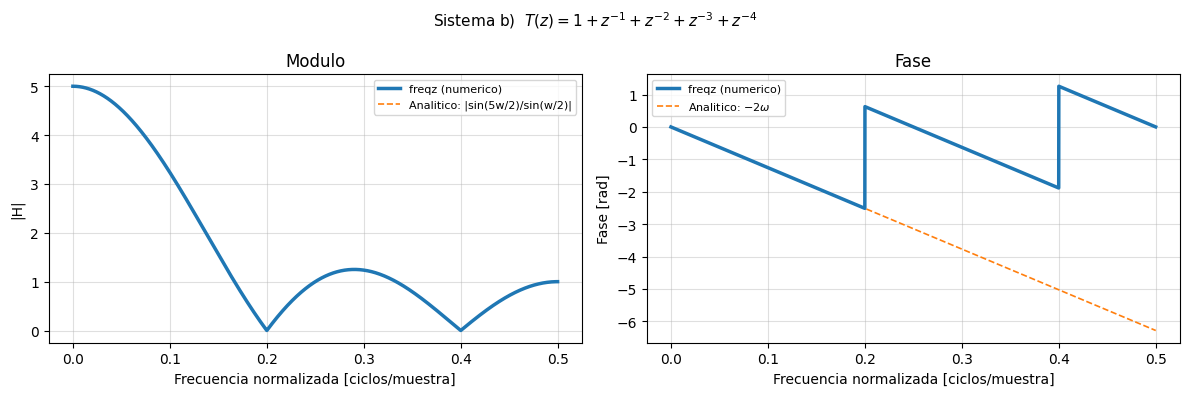

Ganancia en DC (w=0):  numerico = 5.0000,  analitico = 5
Error maximo de modulo: 1.61e-03


In [10]:
b_b = np.array([1, 1, 1, 1, 1])
a_b = np.array([1])

w_b, H_b   = freqz(b_b, a_b, worN=N_w, whole=False)
f_norm_b   = w_b / (2 * np.pi)

w_bn    = np.linspace(1e-9, np.pi, N_w)
H_bnlt  = np.sin(2.5 * w_bn) / np.sin(w_bn / 2)
ph_bn   = -2 * w_bn
f_bn    = w_bn / (2 * np.pi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sistema b)  $T(z) = 1 + z^{-1} + z^{-2} + z^{-3} + z^{-4}$', fontsize=11)

axes[0].plot(f_norm_b, np.abs(H_b),       lw=2.5, label='freqz (numerico)', zorder=3)
axes[0].plot(f_bn,     np.abs(H_bnlt),    lw=1.2, ls='--', color='C1', label='Analitico: |sin(5w/2)/sin(w/2)|')
axes[0].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[0].set_ylabel('|H|')
axes[0].set_title('Modulo')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].plot(f_norm_b, np.unwrap(np.angle(H_b)), lw=2.5, label='freqz (numerico)', zorder=3)
axes[1].plot(f_bn,     ph_bn,                    lw=1.2, ls='--', color='C1', label=r'Analitico: $-2\omega$')
axes[1].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Ganancia en DC (w=0):  numerico = {np.abs(H_b[0]):.4f},  analitico = 5')
print(f'Error maximo de modulo: {np.max(np.abs(np.abs(H_b) - np.abs(H_bnlt))):.2e}')

## Sistema c)

$$y(n) = x(n) - x(n-1)$$

### 1. Funcion de transferencia

$$Y(z) = X(z)\left(1 - z^{-1}\right)$$

$$\boxed{T_c(z) = 1 - z^{-1}}$$

FIR de orden 1. Tiene un cero en $z=1$ ($\omega=0$) y un polo en $z=0$.

### 2. Respuesta en frecuencia

$$H_c(e^{j\omega}) = 1 - e^{-j\omega}
= e^{-j\omega/2}\left(e^{j\omega/2} - e^{-j\omega/2}\right)
= e^{-j\omega/2}\cdot 2j\sin(\omega/2)
= 2\sin(\tfrac{\omega}{2})\cdot e^{j(\pi/2 - \omega/2)}$$

Modulo:
$$|H_c(e^{j\omega})| = 2\left|\sin\!\left(\frac{\omega}{2}\right)\right|$$

Fase:
$$\angle H_c(e^{j\omega}) = \frac{\pi}{2} - \frac{\omega}{2}$$

Es un filtro pasa-altos: nulo en DC ($\omega=0$), maximo en Nyquist ($\omega=\pi$, ganancia = 2).

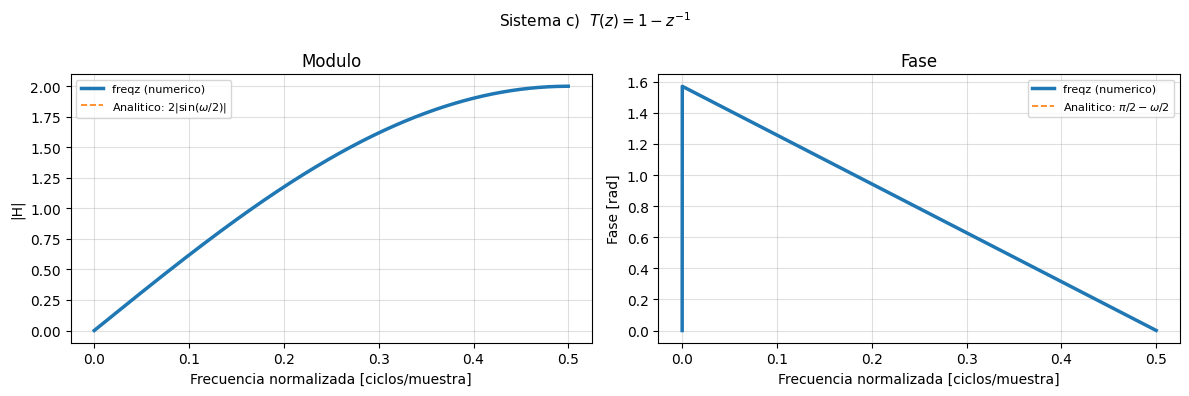

Ganancia en DC (ω=0):       numerico = 0.0000,  analitico = 0
Ganancia en Nyquist (ω=π):  numerico = 2.0000,  analitico = 2
Error maximo de modulo:     2.74e-04


In [11]:
b_c = np.array([1, -1])
a_c = np.array([1])

w_c, H_c   = freqz(b_c, a_c, worN=N_w, whole=False)
f_norm_c   = w_c / (2 * np.pi)

w_cn    = np.linspace(0, np.pi, N_w)
H_cnlt  = 2 * np.abs(np.sin(w_cn / 2))
ph_cn   = np.pi / 2 - w_cn / 2
f_cn    = w_cn / (2 * np.pi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sistema c)  $T(z) = 1 - z^{-1}$', fontsize=11)

axes[0].plot(f_norm_c, np.abs(H_c),    lw=2.5, label='freqz (numerico)', zorder=3)
axes[0].plot(f_cn,     H_cnlt,         lw=1.2, ls='--', color='C1', label='Analitico: $2|\\sin(\\omega/2)|$')
axes[0].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[0].set_ylabel('|H|')
axes[0].set_title('Modulo')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

# la fase analitica π/2 - ω/2 ya es continua, no necesita unwrap
axes[1].plot(f_norm_c, np.unwrap(np.angle(H_c)), lw=2.5, label='freqz (numerico)', zorder=3)
axes[1].plot(f_cn,     ph_cn,                    lw=1.2, ls='--', color='C1', label='Analitico: $\\pi/2 - \\omega/2$')
axes[1].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Ganancia en DC (ω=0):       numerico = {np.abs(H_c[0]):.4f},  analitico = 0')
print(f'Ganancia en Nyquist (ω=π):  numerico = {np.abs(H_c[-1]):.4f},  analitico = 2')
print(f'Error maximo de modulo:     {np.max(np.abs(np.abs(H_c) - H_cnlt)):.2e}')

## Sistema d)

$$y(n) = x(n) - x(n-2)$$

### 1. Funcion de transferencia

$$Y(z) = X(z)\left(1 - z^{-2}\right)$$

$$\boxed{T_d(z) = 1 - z^{-2} = (1 - z^{-1})(1 + z^{-1})}$$

FIR de orden 2. Factoriza en dos sistemas de primer orden: el sistema c) mas el filtro $1+z^{-1}$ (suma de muestras adyacentes). Tiene ceros en $z = \pm 1$, es decir en $\omega = 0$ y $\omega = \pi$.

### 2. Respuesta en frecuencia

$$H_d(e^{j\omega}) = 1 - e^{-j2\omega}
= e^{-j\omega}\left(e^{j\omega} - e^{-j\omega}\right)
= e^{-j\omega}\cdot 2j\sin(\omega)
= 2\sin(\omega)\cdot e^{j(\pi/2 - \omega)}$$

Modulo:
$$|H_d(e^{j\omega})| = 2\left|\sin(\omega)\right|$$

Fase:
$$\angle H_d(e^{j\omega}) = \frac{\pi}{2} - \omega$$

Es un filtro pasa-banda: ceros en DC ($\omega=0$) y en Nyquist ($\omega=\pi$), maximo en $\omega=\pi/2$ (ganancia = 2).

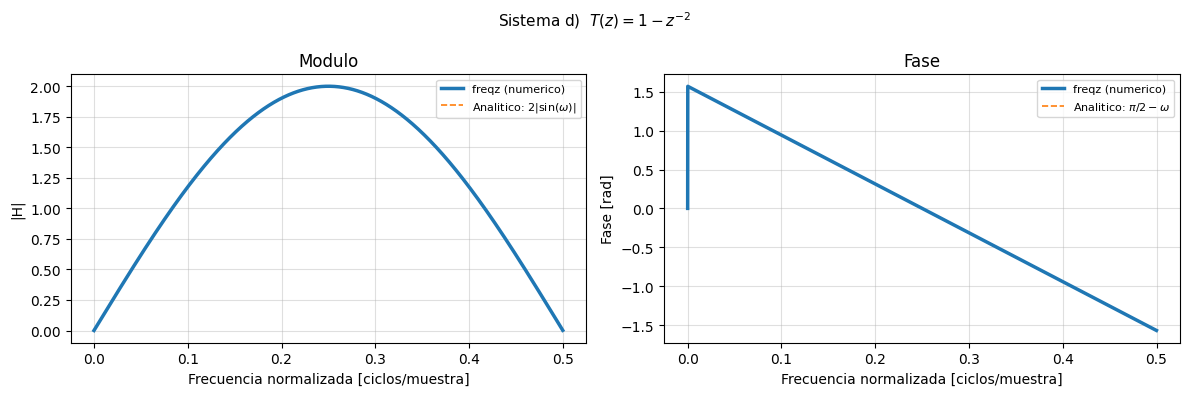

Ganancia en DC (ω=0):           numerico = 0.0000,  analitico = 0
Ganancia en π/2 (ω=π/2):        numerico = 2.0000,  analitico = 2
Ganancia en Nyquist (ω=π):      numerico = 0.0015,  analitico = 0
Error maximo de modulo:         1.53e-03


In [12]:
b_d = np.array([1, 0, -1])
a_d = np.array([1])

w_d, H_d   = freqz(b_d, a_d, worN=N_w, whole=False)
f_norm_d   = w_d / (2 * np.pi)

w_dn    = np.linspace(0, np.pi, N_w)
H_dnlt  = 2 * np.abs(np.sin(w_dn))
ph_dn   = np.pi / 2 - w_dn
f_dn    = w_dn / (2 * np.pi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sistema d)  $T(z) = 1 - z^{-2}$', fontsize=11)

axes[0].plot(f_norm_d, np.abs(H_d),    lw=2.5, label='freqz (numerico)', zorder=3)
axes[0].plot(f_dn,     H_dnlt,         lw=1.2, ls='--', color='C1', label='Analitico: $2|\\sin(\\omega)|$')
axes[0].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[0].set_ylabel('|H|')
axes[0].set_title('Modulo')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].plot(f_norm_d, np.unwrap(np.angle(H_d)), lw=2.5, label='freqz (numerico)', zorder=3)
axes[1].plot(f_dn,     ph_dn,                    lw=1.2, ls='--', color='C1', label='Analitico: $\\pi/2 - \\omega$')
axes[1].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Ganancia en DC (ω=0):           numerico = {np.abs(H_d[0]):.4f},  analitico = 0')
print(f'Ganancia en π/2 (ω=π/2):        numerico = {np.abs(H_d[N_w//2]):.4f},  analitico = 2')
print(f'Ganancia en Nyquist (ω=π):      numerico = {np.abs(H_d[-1]):.4f},  analitico = 0')
print(f'Error maximo de modulo:         {np.max(np.abs(np.abs(H_d) - H_dnlt)):.2e}')

## Comparacion de los cuatro sistemas

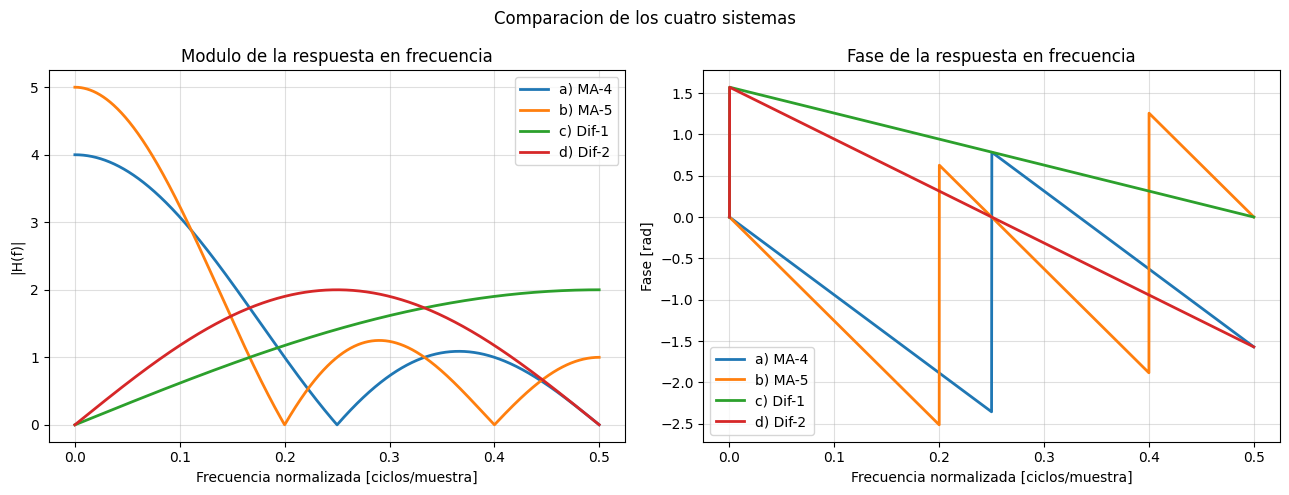

In [13]:
sistemas = [
    ('a) MA-4',  b_a, a_a, 'C0'),
    ('b) MA-5',  b_b, a_b, 'C1'),
    ('c) Dif-1', b_c, a_c, 'C2'),
    ('d) Dif-2', b_d, a_d, 'C3'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparacion de los cuatro sistemas', fontsize=12)

for nombre, b, a, color in sistemas:
    w, H = freqz(b, a, worN=N_w, whole=False)
    f    = w / (2 * np.pi)
    axes[0].plot(f, np.abs(H),             lw=2, color=color, label=nombre)
    axes[1].plot(f, np.unwrap(np.angle(H)), lw=2, color=color, label=nombre)

axes[0].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[0].set_ylabel('|H(f)|')
axes[0].set_title('Modulo de la respuesta en frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].set_xlabel('Frecuencia normalizada [ciclos/muestra]')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase de la respuesta en frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

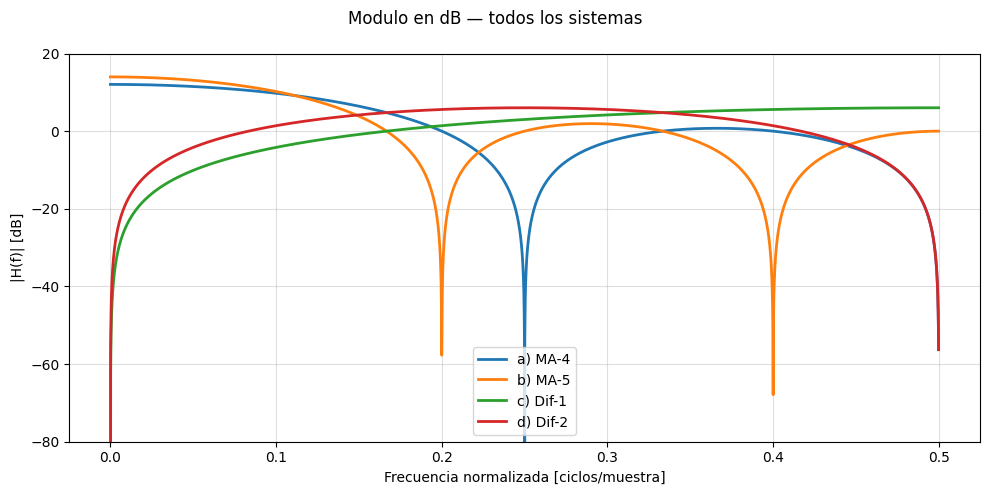

In [14]:
# respuesta en dB para ver mejor los ceros
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Modulo en dB — todos los sistemas', fontsize=12)

for nombre, b, a, color in sistemas:
    w, H = freqz(b, a, worN=N_w, whole=False)
    f    = w / (2 * np.pi)
    ax.plot(f, 20 * np.log10(np.abs(H) + 1e-12), lw=2, color=color, label=nombre)

ax.set_xlabel('Frecuencia normalizada [ciclos/muestra]')
ax.set_ylabel('|H(f)| [dB]')
ax.set_ylim(-80, 20)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Resumen

| Sistema | $T(z)$ | $\lvert H(e^{j\omega})\rvert$ | Tipo | Ceros en |
|:---|:---|:---|:---|:---|
| a) | $1+z^{-1}+z^{-2}+z^{-3}$ | $\lvert\sin(2\omega)/\sin(\omega/2)\rvert$ | Pasa-bajos FIR | $\omega = k\pi/2,\; k=1,2,3$ |
| b) | $1+z^{-1}+z^{-2}+z^{-3}+z^{-4}$ | $\lvert\sin(5\omega/2)/\sin(\omega/2)\rvert$ | Pasa-bajos FIR | $\omega = 2\pi k/5,\; k=1,2,3,4$ |
| c) | $1-z^{-1}$ | $2\lvert\sin(\omega/2)\rvert$ | Pasa-altos FIR | $\omega = 0$ |
| d) | $1-z^{-2}$ | $2\lvert\sin(\omega)\rvert$ | Pasa-banda FIR | $\omega = 0,\;\omega=\pi$ |

Observaciones:
- Los sistemas a) y b) son filtros pasa-bajos: atenuan frecuencias altas y tienen ganancia maxima en DC igual al numero de terminos sumados (4 y 5 respectivamente).
- Aumentar el orden de la media movil (b respecto a a) mejora la atenuacion en altas frecuencias pero reduce el primer nulo a $\omega = 2\pi/5$ (mas cerca del origen que $\omega = \pi/2$).
- El sistema c) es pasa-altos: elimina DC y amplifica Nyquist con ganancia 2.
- El sistema d) factoriza como $T_c(z)\cdot(1+z^{-1})$: el segundo factor elimina Nyquist, resultando en un comportamiento pasa-banda con maximo en $\omega = \pi/2$.
- Todos los filtros tienen fase lineal (son FIR simetricos o antisimetricos), lo que implica retardo de grupo constante.